**Part b**

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
%matplotlib inline
import matplotlib.pyplot as plt
import os

R = 2 * 10**4
T = 10**4
d0 = 10

t = np.arange(T + 1)

rng = np.random.default_rng(2026)

# Current positions only
lamb = np.zeros(R, dtype=np.int32)
lion = np.full(R, d0, dtype=np.int32)

# True = still alive
alive = np.ones(R, dtype=bool)

S1 = np.empty(T + 1)
S1[0] = 1.0

for time in range(1, T + 1):
    idx = alive
    n_alive = idx.sum()

    lamb[idx] += 2 * rng.integers(0, 2, size=n_alive) - 1

    lion[idx] += 2 * rng.integers(0, 2, size=n_alive) - 1

    caught = idx & (lamb == lion)

    alive[caught] = False

    S1[time] = alive.mean()

In [41]:
fit_mask1 = (
    (t >= 10**2) &
    (t <= 10**4) &
    (S1 > 0)
)

slope1, intercept1 = np.polyfit(
    np.log(t[fit_mask1]),
    np.log(S1[fit_mask1]),
    1
)

beta1 = -slope1

print(f"beta_1 = {beta1:.4f}")

beta_1 = 0.4859


**Part c**

In [42]:
rng = np.random.default_rng(2027)

# Current positions only
lamb = np.zeros(R, dtype=np.int32)
lion1 = np.full(R, d0, dtype=np.int32)
lion2 = np.full(R, d0, dtype=np.int32)

# True = still alive
alive = np.ones(R, dtype=bool)

S2 = np.empty(T + 1)
S2[0] = 1.0

for time in range(1, T + 1):
    idx = alive
    n_alive = idx.sum()

    # One shared lamb step
    lamb_step = 2 * rng.integers(0, 2, size=n_alive) - 1

    # Independent lion steps
    lion1_step = 2 * rng.integers(0, 2, size=n_alive) - 1
    lion2_step = 2 * rng.integers(0, 2, size=n_alive) - 1

    lamb[idx] += lamb_step
    lion1[idx] += lion1_step
    lion2[idx] += lion2_step

    # Capture if either lion meets the lamb
    caught = idx & (
        (lamb == lion1) |
        (lamb == lion2)
    )

    alive[caught] = False

    # Survival probability
    S2[time] = alive.mean()

In [43]:
fit_mask2 = (
    (t >= 10**2) &
    (t <= 10**4) &
    (S2 > 0)
)

slope2, intercept2 = np.polyfit(
    np.log(t[fit_mask2]),
    np.log(S2[fit_mask2]),
    1
)

beta2 = -slope2

print(f"beta_2 = {beta2:.4f}")

beta_2 = 0.7447


In [44]:
times = [10**2, 10**3, 10**4]

print("t       S2(t)       S1(t)^2")

for time in times:
    print(
        f"{time:5d}   "
        f"{S2[time]:.6f}   "
        f"{S1[time]**2:.6f}"
    )

t       S2(t)       S1(t)^2
  100   0.350500   0.267237
 1000   0.065800   0.031880
10000   0.011850   0.003295


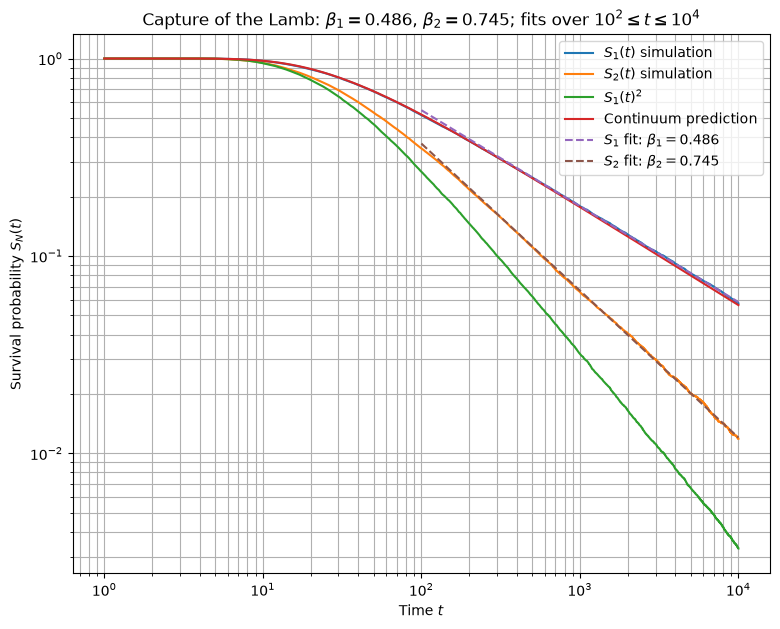

In [46]:
S1_cont = erf(d0 / (2 * np.sqrt(t[1:])))

plt.figure(figsize=(9, 7))

# One-lion simulation
plt.loglog(
    t[1:],
    S1[1:],
    label=r"$S_1(t)$ simulation"
)

# Two-lion simulation
plt.loglog(
    t[1:],
    S2[1:],
    label=r"$S_2(t)$ simulation"
)

# Independence comparison
plt.loglog(
    t[1:],
    S1[1:]**2,
    label=r"$S_1(t)^2$"
)

# Continuum prediction
plt.loglog(
    t[1:],
    S1_cont,
    label=r"Continuum prediction"
)

# Fitted S1 power law
plt.loglog(
    t[fit_mask1],
    np.exp(intercept1) * t[fit_mask1]**slope1,
    "--",
    label=fr"$S_1$ fit: $\beta_1={beta1:.3f}$"
)

# Fitted S2 power law
plt.loglog(
    t[fit_mask2],
    np.exp(intercept2) * t[fit_mask2]**slope2,
    "--",
    label=fr"$S_2$ fit: $\beta_2={beta2:.3f}$"
)

plt.xlabel(r"Time $t$")
plt.ylabel(r"Survival probability $S_N(t)$")

plt.title(
    fr"Capture of the Lamb: "
    fr"$\beta_1={beta1:.3f}$, $\beta_2={beta2:.3f}$; "
    fr"fits over $10^2 \leq t \leq 10^4$"
)

plt.legend()
plt.grid(True, which="both")
plt.savefig(os.path.expanduser("~/Downloads/P4.pdf"), bbox_inches="tight")

plt.show()